# Classification. Part 2
---
Author: Anatoliy Durkin

Updated: 17.03.2025

---
В данном ноутбуке будут рассмотрены несколько моделей классификации, новые функции для метрик и сами новые метрики, а также будет уделено внимание подбору гиперпараметров для моделей.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

В прошлом ноутбуке мы писали функцию, выводившую все необходимые нам метрики вместе. Мы импортировали несколько функций, но в этом ноутбуке используем только две: `confusion_matrix` выводит матрицу ошибок, а `classification_report` выдает остальные метрики, увидим уже на примере. Зачем нужен `fill_diagonal`, увидим в конце ноутбука.

In [2]:
def metrics(target, pred, fill=False):
    print(classification_report(target, pred))
    matrix = np.array(confusion_matrix(target, pred))
    if fill:
        np.fill_diagonal(matrix, 0)
    sns.heatmap(matrix, annot=True, fmt='.0f')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Матрица ошибок')

## Naive Bayes
---

Знаете ли вы метод "съешь лягушку"? Это о том, что нужно выполнить самую неприятную задачу сразу, не откладывая. Так что съедим лягушку и слегка окунёмся в NLP, или Natural language processing - обработка естественного языка.

В этой сфере может быть множество задач классификации, например, отделение спама. Но мы рассмотрим задачу определения кликбейта среди новостных заголовков.

> Кликбейт (англ. clickbait от click «щелчок» + bait «приманка») — уничижительный термин, описывающий веб-контент, целью которого является получение дохода от онлайн-рекламы, особенно в ущерб качеству или точности информации.

А как модель используем наивный байессовский классиикатор.

Итак, познакомимся с данными.

In [3]:
titles = pd.read_csv('titles_data.csv', sep=';')

In [4]:
titles

,titles,target
0,Родственник раскрыл настоящую фамилию Пугачёво...,1
1,Предсказания Матроны Московской на 2024-й год:...,1
2,"Пророчество схимонахини Нины об антихристе, ми...",1
3,«Думал об этом»: что Путин сказал о своем прее...,1
4,Путин поручил уведомить россиян об изменениях ...,1
...,...,...
3193,Путин поручил передать Республике Крым все акц...,0
3194,ЕК изучит просьбу Венгрии по нарушению Болгари...,0
3195,"Глава ""Россетей"" доложил Путину о достижении ц...",0
3196,"Платформа ""Мой экспорт"" научит устанавливать д...",0


Поделим выборку на обучающую и тестовую.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(titles['titles'], titles['target'], test_size=0.2, random_state=42)

Конечно, модели не могут просто так работать с обычным текстом. Необходимы какие-то преобразования. Все модели спокойно работают с числами, значит нужно превратить текст в числа. И тут есть два важных процесса: токенизация и векторизация.

> Токенизация — процесс разбиения текстового документа на отдельные слова, которые называются токенами.

> Векторизация – это термин, обозначающий классический подход к преобразованию входных данных из их исходного формата (например, текста) в векторы действительных чисел, которые понятны моделям машинного обучения.

---
Как мы применим это к нашим данным?

Например, для определения кликбейта можно посчитать, как часто слова встречаются в заголовках. Скорее всего определенные слова могут сигнализировать нам о кликбейте.

В этом нам может помочь `CountVectorizer`, который считает, сколько раз каждое слово встречается в определенной строке.

In [6]:
X_train

3034    Шиитские вооруженные формирования обстреляли а...
2576    Погибшего военкора Журавлева отметили литерату...
533     Кому пересчитают пенсию с 1 ноября: на индекса...
1061    «Вылетела через окно»: страшная гибель жены из...
2626    Депутат Ямпольская выразила соболезнования в с...
                              ...                        
1095    «Больше не наш»: российский певец привел в беш...
1130    Ну и вот и всплыла правда: что заявили в Гнеси...
1294    Задержан экс-боец ЧВК «Вагнер»: что вытворил с...
860     Что делали с пленными женщинами в годы Второй ...
3174    ФАС проанализирует ценообразование на куриные ...
Name: titles, Length: 2558, dtype: str

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

In [8]:
txt = ['мама мыла раму',
      'мама чинила раму',
      'мама мыла, мама чинила']

In [9]:
vectorizer = CountVectorizer()
txt = vectorizer.fit_transform(txt)

In [10]:
# результат
txt.toarray()

array([[1, 1, 1, 0],
       [1, 0, 1, 1],
       [2, 1, 0, 1]])

In [11]:
# словарь
vectorizer.get_feature_names_out()

array(['мама', 'мыла', 'раму', 'чинила'], dtype=object)

Мы получаем таблицу, в которой каждый столбец соответствует слову из сформированного словаря, а строка - фразе из исходного корпуса (набора) текстов. Если взглянуть на таблицу и на словарь, видно, что на пересечении находится количество, сколько раз встречается определенное слово в определенном тексте.

Словарь составляется автоматически в лексикографическом порядке.

Уже здесь вы можете указать на значительное упущение, сделанное мной намеренно, и которое может создать сложности при дальнейшей работе. Об этом поговорим позже, а пока применим векторизатор к нашим даным.

In [12]:
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [13]:
X_train_vec.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2558, 8706))

В библиотеке `sklearn` есть несколько моделей наивного байесса, мы возьмем полиномиальную, она хорошо работает как раз с данной векторизацией.

In [14]:
from sklearn.naive_bayes import MultinomialNB

In [15]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


              precision    recall  f1-score   support

           0       0.89      0.90      0.89       301
           1       0.91      0.90      0.91       339

    accuracy                           0.90       640
   macro avg       0.90      0.90      0.90       640
weighted avg       0.90      0.90      0.90       640



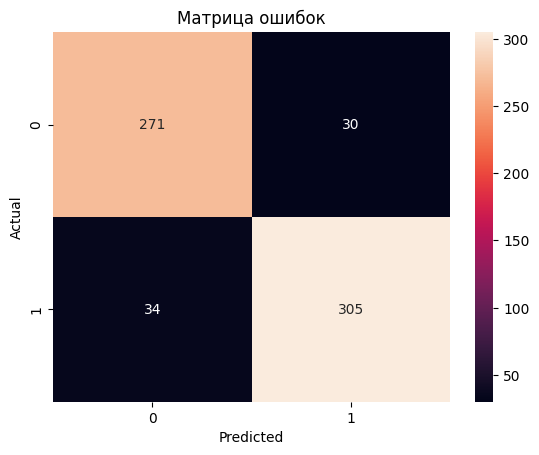

In [17]:
y_pred = model.predict(X_test_vec)
metrics(y_test, y_pred)

Не самые плохие результаты.

Но можно ли улучшить показатели модели? И за счет чего?

---
`CountVectorizer` будет создавать выбросы для слишком асто встречающихся слов, из-за чего будут занижаться значения для некоторых важных слов. Чтобы этого избежать, попробуем использовать другой векторизатор, TF-IDF.

> Термины "TF" (Term Frequency) и "IDF" (Inverse Document Frequency).
>
> TF (Частота термина) обозначает, насколько часто определенное слово появляется в данном документе. Таким образом, TF измеряет важность слова в контексте отдельного документа.
>
> IDF (Обратная частота документа) измеряет, насколько уникально слово является по всей коллекции документов. Слова, которые появляются в большинстве документов, имеют низкое IDF, так как они не вносят большой информационной ценности.

Формула TF-IDF комбинирует понятия TF и IDF, чтобы вычислить важность каждого слова в каждом документе. Формально, формула выглядит следующим образом:

> **TF-IDF(t, d) = TF(t, d) * IDF(t)**

Где:

TF(t, d) - Частота термина (TF) для слова "t" в документе "d".

IDF(t) - Обратная частота документа (IDF) для слова "t".

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

Как выглядит таблица и словарь? Напишите код, чтобы посмотреть.

In [48]:
# Корпус текстов можете заменить по желанию
txt = ['мама мыла раму',
      'мама чинила раму',
      'мама мыла, мама чинила'] 

In [49]:
# Ваш код
vectorizer = TfidfVectorizer()
txt = vectorizer.fit_transform(txt)
txt.toarray()

array([[0.48133417, 0.61980538, 0.61980538, 0.        ],
       [0.48133417, 0.        , 0.61980538, 0.61980538],
       [0.73941068, 0.47606294, 0.        , 0.47606294]])

In [50]:
vectorizer.get_feature_names_out()

array(['мама', 'мыла', 'раму', 'чинила'], dtype=object)

А теперь можно обучить модель с использованием данного векторизатора.

In [51]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [52]:
X_train_tfidf.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(2558, 8706))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       301
           1       0.91      0.91      0.91       339

    accuracy                           0.90       640
   macro avg       0.90      0.90      0.90       640
weighted avg       0.90      0.90      0.90       640



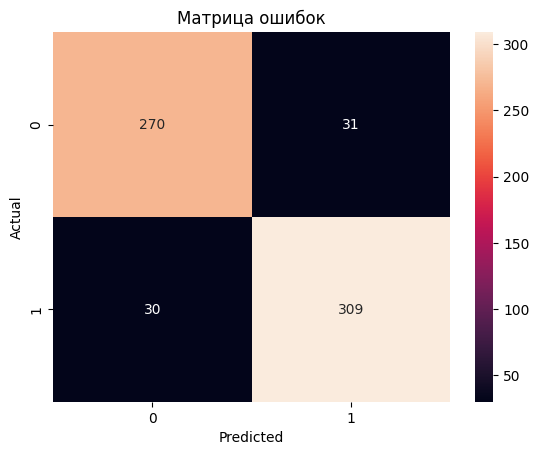

In [53]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)
metrics(y_test, y_pred)

Изменения незначительны. На самом деле это связано с устройством самой модели. Даже в документации вы можете прочитать, что модель работает с дискретными целыми значениями. А TF-IDF, как мы видели, дробный. Однако, отметим, что всё равно модель успешно справилась.

---
Что ещё мы можем сделать?

Конечно, мы пропустили первый и важный этап обработки текста. Токенизация. Нам нужно превратить сплошной текст в набор токенов. Да, если разбитьь текст по пробелу, это тоже токены, однако, у нас в текстах могут встречаться числа и символы (иногда они нужны, но зачастую нет), а также одно и то же слово может быть представлено в различных словоформах (приставки, суффиксы, окончания). Со всем этим нужно работать.

Для борьбы со словоформами можно использовать два разных алгоритма:

> Лемматиза́ция — процесс приведения словоформы к лемме — её нормальной (словарной) форме.

> Сте́мминг (англ. stemming — находить происхождение) — это процесс нахождения основы слова для заданного исходного слова.

Мы используем лемматизацию, для этого подгрузим библиотеку `pymystem3`, разработанную в Яндекс.

In [57]:
# !pip3 install pymystem3
# !pip3 install nltk
from pymystem3 import Mystem
import re
import nltk
from nltk.corpus import stopwords

Мы создадим лемматизатор, а также загрузим список стоп-слов. Это такие слова, которые обычно не несут никакой смысловой нагрузки (союзы, предлоги, etc.).

In [67]:
m = Mystem()
nltk.download('stopwords')
stop_words = list(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to /Users/admin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Вот что получается при работе лемматизатора:

In [63]:
m.lemmatize('Интересного текста много не бывает')

['интересный', ' ', 'текст', ' ', 'много', ' ', 'не', ' ', 'бывать', '\n']

Также накинем регулярные выражения, чтоы оставить в каждом тексте только русские буквы. И лемматизируем полученные тексты.

In [64]:
train_ru = [" ".join(re.sub(r'[^а-яА-ЯёЁ]', ' ', text).split()) for text in X_train.values.astype('U')]
train_full = ' br '.join(train_ru)
train_lem = (''.join([word for word in m.lemmatize(train_full) if word != '\n'])).split(' br ')

test_ru = [" ".join(re.sub(r'[^а-яА-ЯёЁ]', ' ', text).split()) for text in X_test.values.astype('U')]
test_full = ' br '.join(test_ru)
test_lem = (''.join([word for word in m.lemmatize(test_full) if word != '\n'])).split(' br ')

In [66]:
train_lem

['шиитский вооруженный формирование обстреливать американский база в ирак',
 'погибший военкор журавлев отмечать литературный премия',
 'кто пересчитывать пенсия с ноябрь на индексация мочь рассчитывать несколько категория',
 'вылетать через окно страшный гибель жена известный блогер',
 'депутат ямпольская выражать соболезнование в связь со смерть гладков',
 'чтобы сближаться с мужчина просто задавать он этот вопрос',
 'за место в очередь для покупка билет на щелкунчик просить тысяча рубль',
 'музей восток на выставка россия представлять много сто экспонат',
 'в россия представлять отечественный мусоровоз гибрид',
 'путин поручать разрабатывать программа развитие электроэнергетика в дфо',
 'заявление захарова о мус прогреметь на весь мир',
 'ответ знать единица как часто нужно менять губка для мытье посуда',
 'в ран сделать заявление о таинственный инопланетный сигнал',
 'невероятный заявление диетолог мочь ли простой колбаса вызывать онкология',
 'умирать писательница нина садур',
 'м

А теперь к уже обработанному корпусу применим векторизатор и построим модель.

In [68]:
tfidf_vectorizer = TfidfVectorizer(stop_words=stop_words)
X_train_lem = tfidf_vectorizer.fit_transform(train_lem)
X_test_lem = tfidf_vectorizer.transform(test_lem)

              precision    recall  f1-score   support

           0       0.88      0.88      0.88       301
           1       0.90      0.89      0.89       339

    accuracy                           0.89       640
   macro avg       0.89      0.89      0.89       640
weighted avg       0.89      0.89      0.89       640



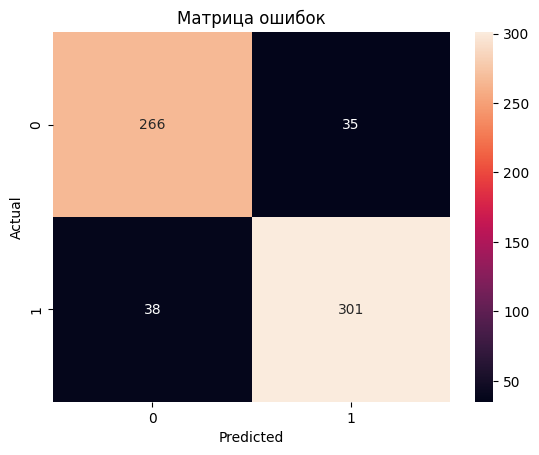

In [69]:
model = MultinomialNB()
model.fit(X_train_lem, y_train)
y_pred = model.predict(X_test_lem)
metrics(y_test, y_pred)

Результат стал даже чуть хуже, но вспомним об особенностях работы модели и попробуем это исправить. Попробуйте получить лучшие метрики.

In [70]:
# Ваш код
...

Ellipsis

## Logistic Regression

---
Переходим к следующей модели.

Для обучения возьмем данные по диабету.

In [71]:
diabetes = pd.read_csv('diabetes_dataset.csv')

In [72]:
X_train, X_test, y_train, y_test = train_test_split(diabetes.drop(['Outcome'], axis=1), diabetes['Outcome'], test_size=0.2, random_state=42)

Для логистической регрессии обязательно нужно нормализовать данные.

In [73]:
from sklearn.preprocessing import StandardScaler

In [74]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [75]:
from sklearn.linear_model import LogisticRegression

In [76]:
clf = LogisticRegression(random_state=42).fit(X_train, y_train)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1275
           1       1.00      0.98      0.99       633

    accuracy                           0.99      1908
   macro avg       0.99      0.99      0.99      1908
weighted avg       0.99      0.99      0.99      1908



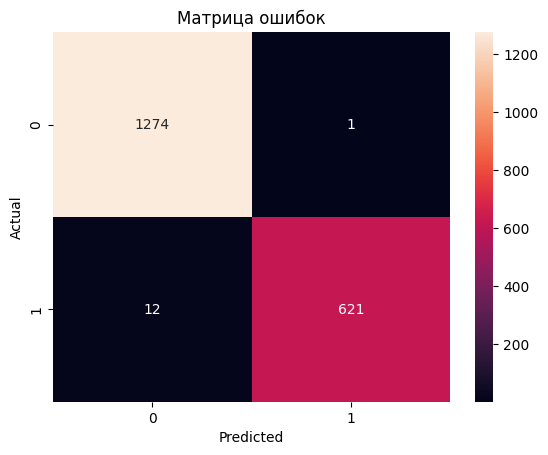

In [78]:
y_pred = clf.predict(X_test)
metrics(y_test, y_pred)

Однако, вы помните, что классы в этом датасете несббалансированны, а это не очень хорошо. Но логистическая модель может сама обучаться с поправкой на дисбаланс, главное указать это в аргументах.

In [79]:
clf = LogisticRegression(class_weight='balanced', random_state=42).fit(X_train, y_train)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1275
           1       1.00      0.99      0.99       633

    accuracy                           1.00      1908
   macro avg       1.00      0.99      0.99      1908
weighted avg       1.00      1.00      1.00      1908



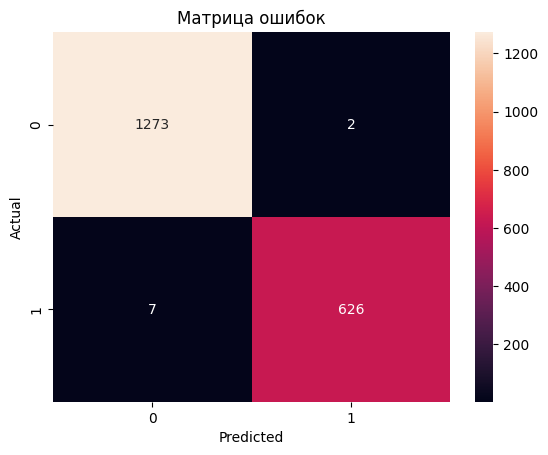

In [80]:
y_pred = clf.predict(X_test)
metrics(y_test, y_pred)

Рассмотрим ещё две метрики, позволяющие оценить качество модели. ROC-кривая и ROC-AUC.

---
Для построения этих показателей необходимо рассмотреть изменение порога классификации. Поскольку у нас всего два класса, можно рассматривать вероятность получения класса "1". По умолчанию порог равен 0.5 - получили значение выше 0.5, класс "1", ниже - "0".

Но этот порог можно изменять. Как будут вести себя точность и полнота, если снизить порог до 0.3? А если повысить до 0.8?

У логистической регрессии есть метод `predict_proba`, который автоматически считает вероятности для классов при различном пороге классификации.

In [85]:
from sklearn.metrics import roc_curve, roc_auc_score

In [86]:
proba = clf.predict_proba(X_test)
proba_one = proba[:, 1]

In [93]:
proba

array([[8.78218188e-01, 1.21781812e-01],
       [3.10591431e-08, 9.99999969e-01],
       [9.94601126e-01, 5.39887441e-03],
       ...,
       [9.95488567e-01, 4.51143275e-03],
       [1.17832488e-06, 9.99998822e-01],
       [9.99281435e-01, 7.18565234e-04]], shape=(1908, 2))

In [94]:
proba_one

array([1.21781812e-01, 9.99999969e-01, 5.39887441e-03, ...,
       4.51143275e-03, 9.99998822e-01, 7.18565234e-04], shape=(1908,))

Нам нужны два важных значения. Вспомним матрицу ошибок

---
|           | Predicted: 0 | Predicted:1 |
|-----------|:------------:|:-----------:|
| Actual: 0 | TN           | FP          |
| Actual: 1 | FN           | TP          |

---
$TPR = \frac{TP}{TP+FN}$

$FPR = \frac{FP}{FP+TN}$

Что отражают TPR и FPR?

In [95]:
fpr, tpr, thresholds = roc_curve(y_test, proba_one)

Text(0.5, 1.0, 'ROC-кривая')

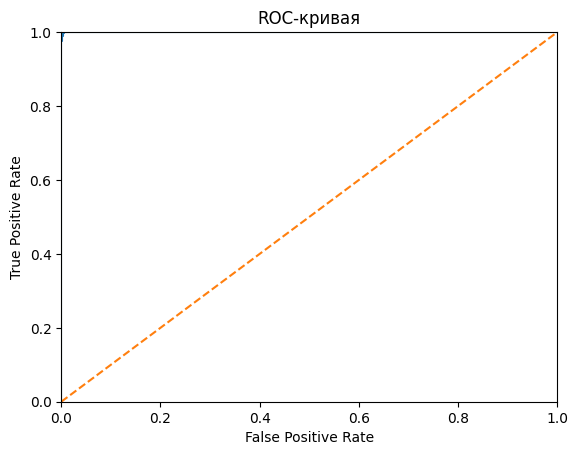

In [98]:
plt.figure()
plt.plot(fpr, tpr)

# ROC-кривая случайной модели (выглядит как прямая)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlim([0, 1])
plt.ylim([0, 1])
# plt.axis('off') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')

Для данной модели ROC-кривая почти идеальна, это замечательно. А метрика AUC-ROC - это площадь под ROC-кривой.

In [99]:
auc_roc = roc_auc_score(y_test, y_pred)
print('AUC-ROC:',auc_roc)

AUC-ROC: 0.993686460366137


## Random Forest

---
Переходим к ансамблевому методу обучения.

Что такое ансамбль? Нет, не песни и пляски, а применительно к нашей теме.

> Ансамблевый метод - метод машинного обучения, где несколько моделей обучаются для решения одной и той же проблемы и объединяются для получения лучших результатов.

---
Есть два наиболее популярных класса ансаблевых методов: бэггинг и бустинг. О первом мы поговорим сейчас, а второй оставим на будущие темы.

> Бэггинг (от англ. bootstrap aggregating, бутстрэп-агрегирование) — ансамблевый метаалгоритм, предназначенный для улучшения стабильности и точности алгоритмов машинного обучения, используемых в задачах классификации и регрессии. Алгоритм также уменьшает дисперсию и помогает избежать переобучения.

Если задан стандартный тренировочный набор $D$ размера $n$, бэггинг образует $m$ новых тренировочных наборов $D_i$, каждый размером $n′$, путём выборки из $D$ равномерно и с возвратом. При семплинге с возвратом некоторые наблюдения могут быть повторены в каждой $D_i$. Этот вид семплинга известен как бутстрэп-семплинг. Эти $m$ моделей сглаживаются с помощью вышеупомянутых $m$ бутстрэп-выборок и комбинируются путём усреднения (для регрессии) или голосования (для классификации).

---
Именно так и устроен случайный лес. Но прежде чем обратиться к обучению моделей, пара слов о подготовке данных и выборе признаков. Используем всё те же данные по диабету.

In [100]:
diabetes

,Age,Pregnancies,BMI,Glucose,BloodPressure,HbA1c,LDL,HDL,Triglycerides,WaistCircumference,HipCircumference,WHR,FamilyHistory,DietType,Hypertension,MedicationUse,Outcome
0,69,5,28.39,130.1,77.0,5.4,130.4,44.0,50.0,90.5,107.9,0.84,0,0,0,1,0
1,32,1,26.49,116.5,72.0,4.5,87.4,54.2,129.9,113.3,81.4,1.39,0,0,0,0,0
2,89,13,25.34,101.0,82.0,4.9,112.5,56.8,177.6,84.7,107.2,0.79,0,0,0,1,0
3,78,13,29.91,146.0,104.0,5.7,50.7,39.1,117.0,108.9,110.0,0.99,0,0,0,1,1
4,38,8,24.56,103.2,74.0,4.7,102.5,29.1,145.9,84.1,92.8,0.91,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9533,32,3,23.00,102.3,62.0,4.1,109.3,47.8,76.7,86.8,115.0,0.75,0,0,0,0,0
9534,74,0,24.29,125.8,93.0,5.3,95.8,66.6,103.7,90.1,94.3,0.96,1,0,0,1,1
9535,75,6,26.10,107.6,75.0,5.0,168.5,62.3,149.8,84.0,114.9,0.73,0,0,0,1,0
9536,52,1,25.88,99.3,96.0,4.6,70.0,48.4,122.9,97.5,88.7,1.10,1,0,0,0,1


Конечно, мы схитрим и изначально не будем использовать признак `FamilyHistory`, чтобы заведемо снизить качество модели.

Но у нас остаётся ещё 15 признаков. Да, это не так уж много, это не 200 признаков, когда их число точно хочется сократить. Но иногда и при небольшом количестве признаков стоит подумать и, возможно, от чего-то избавиться.

Один из простых шагов - убрать сильно коррелированные переменные.

Сильно коррелированные друг с другом переменные дают модели одну и ту же информацию, следовательно, для анализа не нужно использовать их все. Например, если набор данных (dataset) содержит признаки «Время в сети» и «Использованный трафик», можно предположить, что они будут в некоторой степени коррелированы, и мы увидим сильную корреляцию, даже если выберем непредвзятый образец данных. В таком случае в модели нужна только одна из этих переменных. Если использовать обе, то модель окажется переобучена (overfit) и предвзята относительно одного отдельного признака.

Посмотрите на корреляционную матрицу и поищите, какие признаки могут быть удалены.

<Axes: title={'center': 'Корреляционная матрица'}>

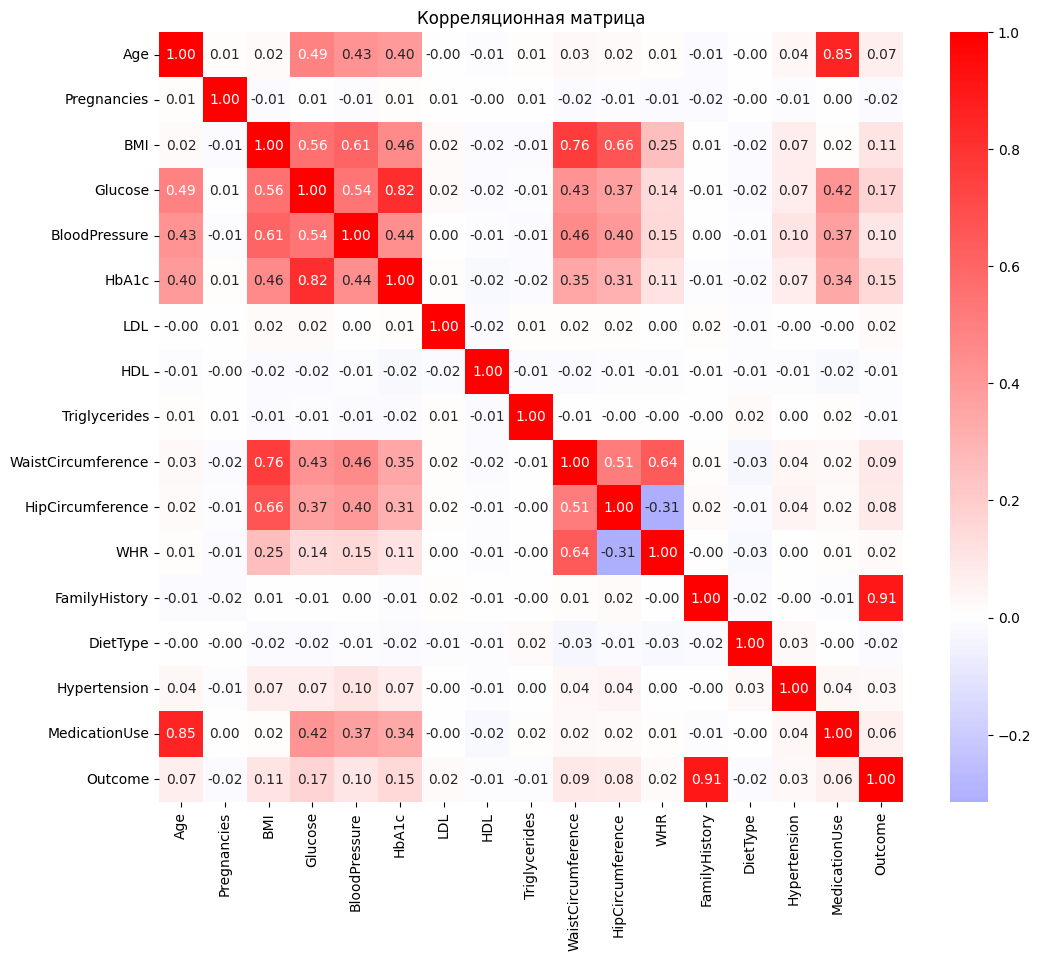

In [101]:
plt.figure(figsize=(12,10))
plt.title('Корреляционная матрица')
sns.heatmap(diabetes.corr(), cmap='bwr', center=0, annot=True, fmt='.2f')

Обучим простую модель случайного леса. Исключаю `FamilyHistory` для снижения метрик, глубину деревьев беру рандомно, число никак не подбиралось.

In [102]:
from sklearn.ensemble import RandomForestClassifier

In [103]:
X_train, X_test, y_train, y_test = train_test_split(diabetes.drop(['Outcome', 'FamilyHistory'], axis=1), diabetes['Outcome'], test_size=0.2, random_state=42)

In [114]:
rf = RandomForestClassifier(max_depth=15, random_state=42).fit(X_train, y_train)

              precision    recall  f1-score   support

           0       0.71      1.00      0.83      1275
           1       0.96      0.17      0.29       633

    accuracy                           0.72      1908
   macro avg       0.84      0.58      0.56      1908
weighted avg       0.79      0.72      0.65      1908



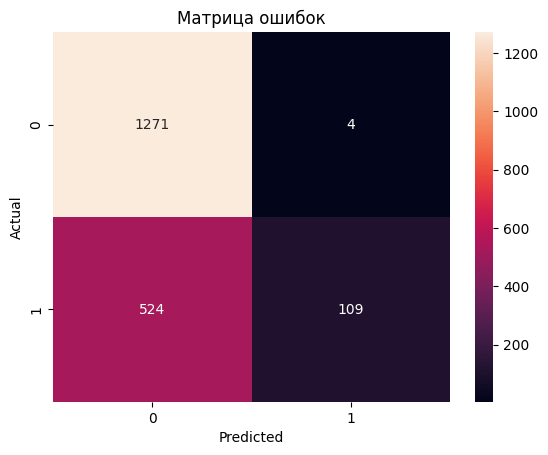

In [115]:
metrics(y_test, rf.predict(X_test))

А теперь повторим процесс, но из признаков исключим также `HbA1c`. Он сильно коррелирует с `Glucose`, а значит, они несут очень схожую информацию для модели. Посмотрим, к чему это приведет.

In [106]:
X_train, X_test, y_train, y_test = train_test_split(diabetes.drop(['Outcome', 'FamilyHistory', 'HbA1c'], axis=1), diabetes['Outcome'], test_size=0.2, random_state=42)

In [116]:
rf = RandomForestClassifier(max_depth=8, random_state=42).fit(X_train, y_train)

              precision    recall  f1-score   support

           0       0.71      1.00      0.83      1275
           1       0.97      0.17      0.29       633

    accuracy                           0.72      1908
   macro avg       0.84      0.58      0.56      1908
weighted avg       0.80      0.72      0.65      1908



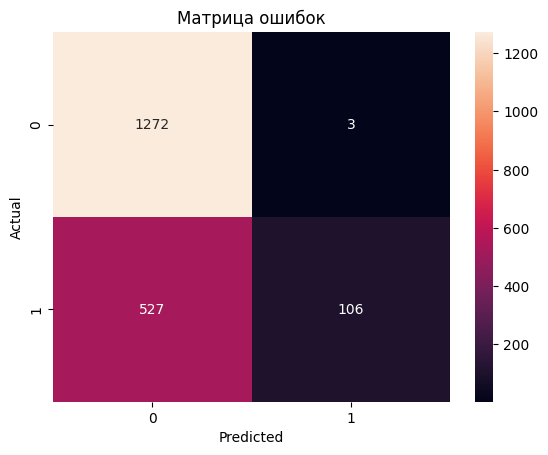

In [117]:
metrics(y_test, rf.predict(X_test))

Изменения почти отсутсвуют, но всё же есть, и в лучшую сторону. Значит такой подход к выбору признаков работает.

Есть множество способов отбора признаков, о некоторых поговорим, когда будем работать с регрессией.

А ещё можно посмотреть на важность признаков в обученной модели с помощью метода `feature_importances_`.

In [118]:
pd.Series(data=rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

Glucose               0.511443
BMI                   0.075135
WaistCircumference    0.057090
HipCircumference      0.055480
HDL                   0.050263
Age                   0.046386
LDL                   0.044909
BloodPressure         0.044728
Triglycerides         0.043010
WHR                   0.034251
Pregnancies           0.021457
DietType              0.008098
MedicationUse         0.007528
Hypertension          0.000222
dtype: float64

Попробуйте построить ту же модель, исключив неважные признаки, изменится ли качество.

In [129]:
# Ваш код
X_train, X_test, y_train, y_test = train_test_split(diabetes[['Glucose']], diabetes['Outcome'], test_size=0.2, random_state=42)


In [130]:
rf = RandomForestClassifier(max_depth=8, random_state=42).fit(X_train, y_train)

              precision    recall  f1-score   support

           0       0.71      1.00      0.83      1275
           1       1.00      0.17      0.28       633

    accuracy                           0.72      1908
   macro avg       0.85      0.58      0.56      1908
weighted avg       0.80      0.72      0.65      1908



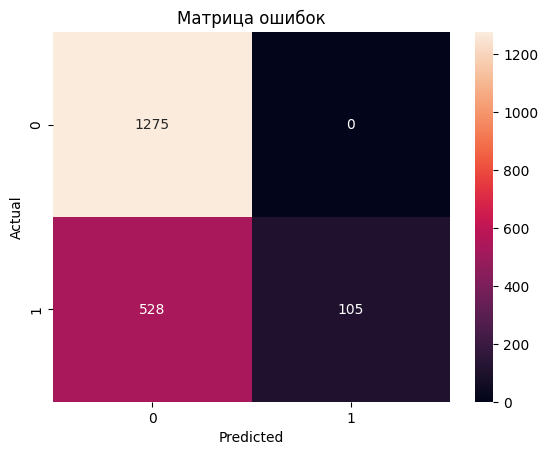

In [131]:
metrics(y_test, rf.predict(X_test))

Также посмотрим на ROC-кривую для такой модели (у случайного леса тоже есть такие методы).

In [132]:
fpr, tpr, thresholds = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])

Text(0.5, 1.0, 'ROC-кривая')

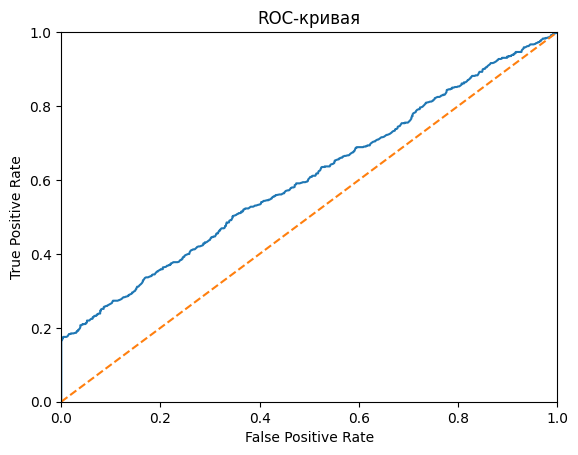

In [133]:
plt.figure()
plt.plot(fpr, tpr)

# ROC-кривая случайной модели (выглядит как прямая)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlim([0, 1])
plt.ylim([0, 1])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')

In [134]:
auc_roc = roc_auc_score(y_test, rf.predict(X_test))
print(auc_roc)

0.5829383886255924


## GridSearchCV

---
В прошлый раз мы говорили о кросс-валидации, которая помогает получить более правильные метрики при усреднении нескольких моделей.

Но куда важнее для модели подобрать нужные гиперпараметры, от этого зависит очень многое, метрики могут отличаться значительно. Самое простое, что можно сделать - ручной перебор, меняем гиперпараметр, обучаем, проверяем, и так по кругу, пока не получим оптимальный результат. Но, это скучно и утомительно, поэтому можно воспользоваться `GridSearchCV`, который проделает тот же процесс самостоятельно. Более того, он попутно проводит и кросс-валидацию.

In [192]:
X_train, X_test, y_train, y_test = train_test_split(diabetes.drop(['Outcome', 'FamilyHistory'], axis=1), diabetes['Outcome'], test_size=0.2, random_state=42)

In [193]:
rf = RandomForestClassifier()

In [194]:
from sklearn.model_selection import GridSearchCV

В `SridSearchCV` мы передаем нужную нам модель и перечень гиперпараметров, которые хотим варьировать, с желаемыми значениями. Также можно указать, на сколько частей бить данные при кросс-валидации, и желаемую метрику. Сколько раз будет обучаться модель при следующих параметрах?

In [195]:
parameters = {'max_depth': [5, 8, 10, 12, 14], 'n_estimators': [50, 100, 110, 120, 130], 'random_state': [42]}
clf = GridSearchCV(rf, parameters, cv=5, scoring='roc_auc')
clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 8, ...], 'n_estimators': [50, 100, ...], 'random_state': [42]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

А после обучения можно посмотреть на лучшую оценку, лучшую модель и просто посмотреть на все результаты обучения.

In [196]:
clf.best_score_

np.float64(0.5998033092249747)

In [197]:
clf.best_params_

{'max_depth': 12, 'n_estimators': 100, 'random_state': 42}

In [198]:
clf.cv_results_

{'mean_fit_time': array([0.23882251, 0.46702132, 0.51097307, 0.5530839 , 0.59916234,
        0.3344605 , 0.66713867, 0.73069286, 0.79545727, 0.8609602 ,
        0.398103  , 0.794449  , 0.8732058 , 0.9533618 , 1.02984467,
        0.45946059, 0.91633673, 1.00594258, 1.0962656 , 1.18618846,
        0.51238647, 1.02492661, 1.1298038 , 1.23136439, 1.33231273]),
 'std_fit_time': array([0.00375128, 0.00236778, 0.00254261, 0.00186975, 0.00382127,
        0.00241016, 0.00203572, 0.00342353, 0.00408685, 0.00329303,
        0.00079545, 0.00385316, 0.00506644, 0.00673239, 0.00565831,
        0.00159502, 0.00211583, 0.0023691 , 0.00385757, 0.00416019,
        0.00096785, 0.00432537, 0.00505485, 0.00415133, 0.00526004]),
 'mean_score_time': array([0.00737524, 0.01188607, 0.0126986 , 0.01349878, 0.01458335,
        0.00851221, 0.01509924, 0.01648521, 0.01772485, 0.01921782,
        0.0097476 , 0.01795998, 0.01971416, 0.02156076, 0.02304492,
        0.01111941, 0.02066193, 0.02274961, 0.02452016, 0.02

Попробуйте использовать `GridSearchCV` с тем набором признаков, который считаете оптимальным. Подберите лучший набор гиперпараметров, выберите метрику и посмотрите, какого результата сможете достичь.

Метрики можно посмотреть тут: [scoring-parameter](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter)

CPU times: user 3 μs, sys: 1 μs, total: 4 μs
Wall time: 9.3 μs
              precision    recall  f1-score   support

           0       0.71      1.00      0.83      1275
           1       0.95      0.17      0.28       633

    accuracy                           0.72      1908
   macro avg       0.83      0.58      0.55      1908
weighted avg       0.79      0.72      0.65      1908



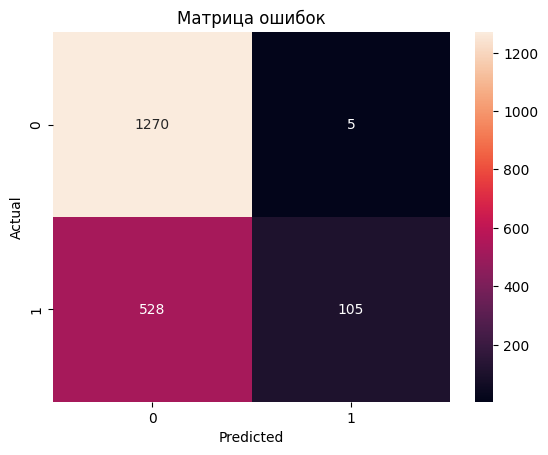

In [203]:
%time
X_train, X_test, y_train, y_test = train_test_split(diabetes.drop(['Outcome', 'FamilyHistory'], axis=1), diabetes['Outcome'], test_size=0.2, random_state=42)
rf = RandomForestClassifier(max_depth=12, random_state=42, n_estimators=100).fit(X_train, y_train)
metrics(y_test, rf.predict(X_test))

In [204]:
fpr, tpr, thresholds = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])

Text(0.5, 1.0, 'ROC-кривая')

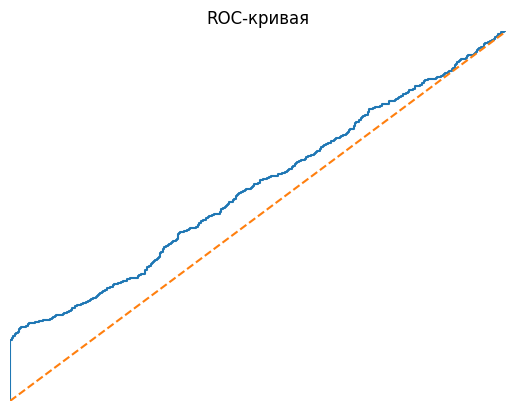

In [205]:
# Ваш код
plt.figure()
plt.plot(fpr, tpr)

# ROC-кривая случайной модели (выглядит как прямая)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlim([0, 1])
plt.ylim([0, 1])
plt.axis('off')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')

In [206]:
auc_roc = roc_auc_score(y_test, rf.predict(X_test))
print(auc_roc)

0.580977604311867


## Multiclass classification

---
Всюду до этого мы рассматривали случаи бинарной классификации, где у нас были только два класса. Однако зачастую нам нужно классифицировать данные по нескольким группам. Есть два подхода к использванию бинарных классификаторов для многоклассовой классификации.

> Один против всех (One-versus-all, OvA или один против остальных, One-versus-rest, OvR). Для каждого класса строится один бинарный классификатор. При этом примеры класса определяются как «положительные», а всех других — как «отрицательные». Итоговый результат формируется по принципу «победитель получает все»: объект будет отнесен к классу, для которого бинарный классификатор даст большее число «положительных» примеров.

> Один против одного (One versus One, OvO). Строится $k(k−1)$ классификаторов, позволяющих различить любую пару примеров разных классов. Алгоритм просматривает все пары примеров с разными метками классов и для каждой решает бинарную задачу $f_{ij}$. В каждом случае для пар $(i,j)$ положительные — все примеры с метками $i$, а отрицательными — с $j$.

Какие недостатки можно отметить у обоих способов?

Но многие модели просто умеют работать с несколькими классами. Например, случайный лес делает это легко.

Для демонстрации загрузим новые данные.

Этот набор данных содержит исчерпывающую информацию о 2392 учениках старших классов, в которой подробно описываются их демографические данные, привычки в учебе, участие родителей, внеклассные мероприятия и успеваемость. Целевая переменная, `GradeClass`, классифицирует оценки учеников по отдельным категориям, предоставляя надежный набор данных для образовательных исследований, прогнозного моделирования и статистического анализа.

In [208]:
# stud = pd.read_csv('Student_performance_data.csv')

In [ ]:
stud

Теперь обучим модель и посмотрим на метрики.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(stud.drop(['GradeClass'], axis=1), stud['GradeClass'], test_size=0.2, random_state=42)

In [ ]:
rf = RandomForestClassifier(max_depth=8).fit(X_train, y_train)

In [ ]:
metrics(y_test, rf.predict(X_test))

Как видим, теперь для каждого класса у нас есть набор метрик, а также общие оценки.

И тепловая карта с матрицей ошибок выглядит лучше. Однако на ней заметен дисбаланс классов. А когда мы хотим оценить, где модель делает наибольшие ошибки, нам лучше занулить диагональ. Для этого в нашей функции `metrics` предусмотрен код.

In [ ]:
metrics(y_test, rf.predict(X_test), True)

Тут видно, где модель ошибается боьше всего.

В завершение предлагаю вам настроить и эту модель, подобрав лучшие гиперпараметры.

In [ ]:
# Ваш код
...